# Part 5: Bayesian Inference for Quantum Amplitude Estimation
#### *Tutorial by [Alexandra Ramôa](https://sites.google.com/view/alexandraramoa)*

In this tutorial we consider one more quantum application for Bayesian inference: iterative quantum algorithms. In particular, we will look into quantum amplitude estimation (QAE). To motivate the problem, we start by taking a high level view of hybrid quantum algorithms, Grover search and quantum amplitude estimation.



## Installs and imports

In [1]:
%%capture
!pip install qiskit
!pip install pylatexenc
!pip install qiskit_aer

In [2]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import brute

## 5.1 Hybrid quantum-classical algorithms

Standard quantum algorithms, such as Shor's or Grover's, usually take the form of a long quantum circuit: sequence of quantum operations followed by measurement (and eventually some classical post-processing). However, today's quantum devices cannot run this: they suffer from problems such as *decoherence*, which limits the amount of operations one can fruitfully execute.

Building a functioning quantum computer is a huge engineering challenge. While we wait for engineers to accomplish it, we can entertain ourselves by looking for algorithms that are more lenient towards the hardware. This typically takes the form of shorter quantum circuits, intercalated with classical processing. The algorithmic workflow is:
1. The quantum device runs a (simplified) sequence of operations and measurements.
2. The classical device receives the quantum measurement results and chooses the quantum circuit to run next.
3. Return to 1 (until some problem-specific termination criterion is met).

This is the case of, for instance, the QAOA (quantum approximate optimization algorithm) and VQE (variational quantum eigensolver). It can also be the case of quantum amplitude estimation (QAE), which we will talk about today.

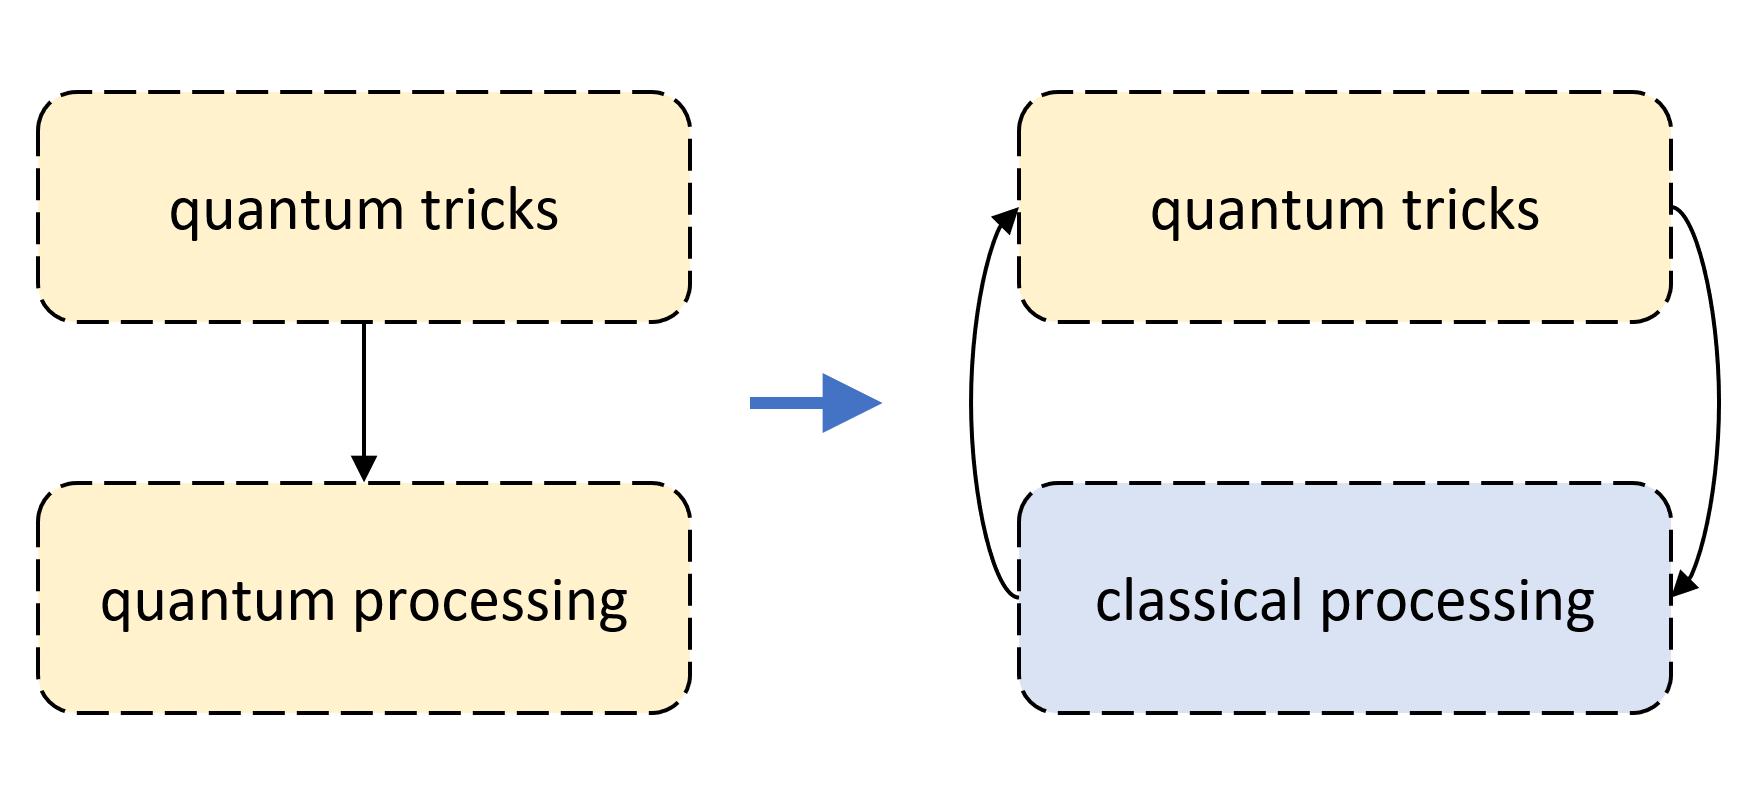

Quantum amplitude estimation borrows from the framework of Grover search, so we will briefly introduce it before proceeding.

## 5.2 Grover search

[Grover's algorithm](https://arxiv.org/pdf/quant-ph/9605043) offers a quadratic quantum speed-up for unstructured database search.

Consider this problem statement: we have $n$ bits, and there exists a single *good *bitstring (among all $N:=2^n$ options) which satisfies a given property. Given any bitstring, we can check whether the property is satisfied. We want to find the good bitstring, while checking the fewest possible bitstrings.

In the general case, we can *identify* this bitstring easily, but not necessarily find it (think about e.g. Sudoku!). The only possible classical strategy is to randomly pick one string at a time, check whether it satisfies the property, and keep trying if it does not. The success probability for each trial is $1/N$. The cost is $N$ [checking operations] in the worst case, and $N/2$ in the average case.

In the quantum case, we can get more creative. Thanks to quantum interference, we can orchestrate a sequence of operations that increases the probability of measuring the good bitstring. This process is called **quantum amplitude amplification**.

We initialize the circuit (using standard operations, often Hadamards for a uniform superposition) and then apply a special operator, called the Grover operator, $m$ times. This operator consists of two reflections that rotate the state closer to the good bitstring as $m$ increases. Thus, the success probability (probability of measuring the good bitstring) can be brought up to $100\%$*. More specifically:

$$
P(\text{good} \mid m) = \sin^2((2m+1)\theta_a)
$$

with the angle defined as $\theta_a = \arcsin (\sqrt a)$.

**Note*: Here $m$ is a number of iterations. For most amplitudes, restricting values of $m$ to integers prevents us from making it coincide exactly with $\pi/2$, which is necessary to get $100\%$ success probability. However, there are ways of realizing fractionary $m$s (using an auxiliary qubit or generalized rotations instead of reflections). Furthermore, even we do not do this, we can at least achieve _very high probability_ of success, especially for small amplitudes - which are the cases of interest here.

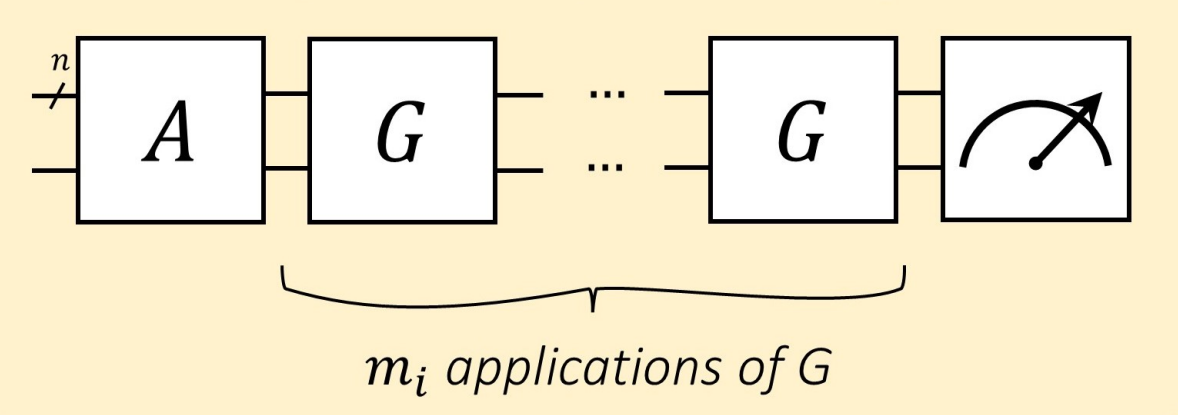

These operations have a cost: the *checking* operation translates into an *oracle* that identifies quantum state corresponding to the bitstring, and is used to build the Grover operator. However, even when this cost is factored in, the quantum algorithm offers a quadratic speed-up: the cost is only $\mathcal O (\sqrt N)$.

Notice how remarkable this is: if we increase the number of possibilities by a factor of $100$, the classical approach becomes $100$ times slower. This is expected, because we have $100$ times more bitstrings to look through. However, the quantum algorithm becomes only $10$ times slower!

To learn more about Grover search, check out [this tutorial](https://pennylane.ai/qml/demos/tutorial_grovers_algorithm) (note it uses a different quantum library than we used here: PennyLane instead of Qiskit).

Below we implement a simple demonstration of Grover search, where the "good bitstring" is simply the all-ones sequence.

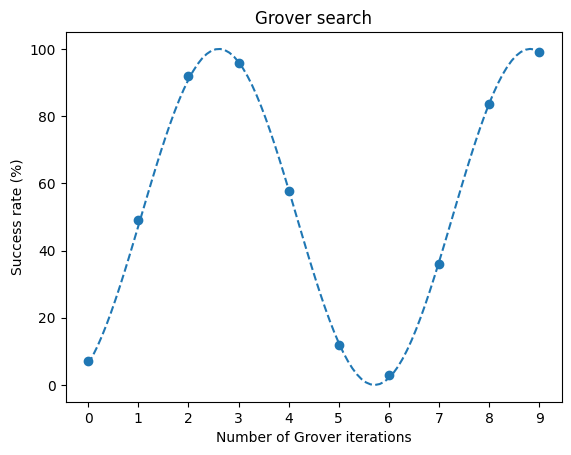

In [3]:
nqubits = 4
goodstate = "1" * nqubits
a_true = 1/2**nqubits
nshots = 1024

sim = AerSimulator()

def oracle(qc):
    if nqubits == 1:
        qc.z(0)
    else:
        qc.h(nqubits - 1)
        qc.mcx(list(range(nqubits - 1)), nqubits - 1)   # marks |11...1>
        qc.h(nqubits - 1)

def diffuser(qc):
    qc.h(range(nqubits))
    qc.x(range(nqubits))
    if nqubits == 1:
        qc.z(0)
    else:
        qc.h(nqubits - 1)
        qc.mcx(list(range(nqubits - 1)), nqubits - 1)
        qc.h(nqubits - 1)
    qc.x(range(nqubits))
    qc.h(range(nqubits))

def grover_good_counts(ms):
    out = []
    for m in ms:
        qc = QuantumCircuit(nqubits, nqubits)
        qc.h(range(nqubits))
        for _ in range(m):
            oracle(qc)
            diffuser(qc)
        qc.measure(range(nqubits), range(nqubits))
        tqc = transpile(qc, sim)
        counts = sim.run(tqc, shots=nshots).result().get_counts()
        out.append(counts.get(goodstate, 0))
    return out

def grover_plot(ms, ys):
    plt.figure()
    plt.scatter(ms, [y*100/nshots for y in ys])
    plt.xlabel("Number of Grover iterations")
    plt.ylabel("Success rate (%)")
    plt.title("Grover search")

    ms_denser = np.linspace(min(ms), max(ms), 100)
    sins = [np.sin((2*m+1)*np.arcsin(np.sqrt(1/2**nqubits))) for m in ms_denser]
    plt.plot(ms_denser, [s**2*100 for s in sins], linestyle="--")

    from matplotlib.ticker import MaxNLocator
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

ms = [i for i in range(10)]
ys = grover_good_counts(ms)
grover_plot(ms, ys)

As you can see, the success rate (percentage of times a measurement yields the correct state) oscillates between $0$ and $100\%$ as we vary the number of Grover iterations. As long as we know what percentage of states is *good* (in this case, $1/N$) we can easily calculate the number of iterations that maximizes the success probability; here we would stop at iteration 3 to get a near-unit success rate.

However, in some cases, we do not know. Finding this percentage is precisely the task that quantum amplitude estimation solves.

## 5.3 Quantum amplitude estimation

Consider this new (related) problem statement: we have $n$ bits, and there exists an unknown amount of *good* bitstrings (among all $N:=2^n$ options) which satisfy a given property. Given any bitstring, we can check whether the property is satisfied. We want to estimate what fraction of bitstrings is good, while checking the fewest possible bitstrings.

We call this fraction the *amplitude* $a$, and this problem [amplitude estimation](https://arxiv.org/pdf/quant-ph/0005055). It is a very useful routine, with applications in chemistry, machine learning, and finance.

Once more, the classical solution doesn't allow much creativity. We sample some number $K$ of strings at random, and check how many of them are good; if we get $l$ good bitstrings, we estimate the fraction as $l/K$. The estimation error shrinks with the cost $K$ as $\mathcal O (1/\sqrt K)$ (standard error of the mean).

The quantum case is again more interesting: we can exploit quantum amplitude amplification again. It turns out that the amplitude we're trying to estimate is directly related to the eigenvalues of the Grover operator, which we can find via quantum phase estimation. This gets us again a quadratic speed up: the error decreases as $\mathcal O (1/ K)$.

However, this very much qualifies as a too-complex circuit for the quantum devices of the near future:

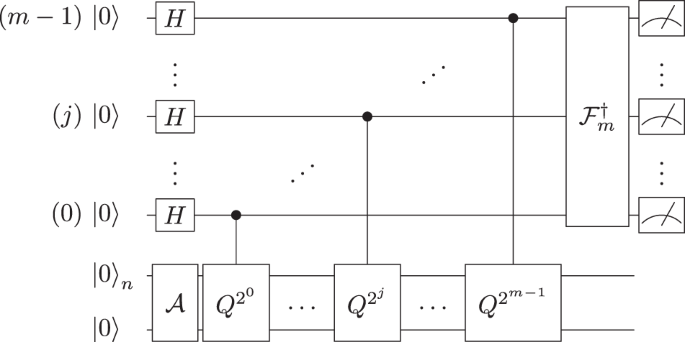

Instead, we can look at the problem differently, and follow the hybrid template of section 5.1.

## 5.4 Hybrid quantum amplitude estimation

The idea here is to forget about phase estimation, and consider the basic Grover circuits of section 5.2. They allow us to collect different data than is possible classically, which may be useful for learning.

In the classical case, amplitude estimation is the problem of estimating the parameter of a binomial probability distribution by sampling from it: $\texttt{Binomial} (a)$, or equivalently, $\texttt{Binomial} (\sin^2 (\theta_a))$.

If we have access to the Grover circuits of section 5.2, the distribution we can sample from becomes:

$$
\texttt{Binomial} (\sin^2((2m+1)\theta_a))
$$

The classical case is just a particular instance of this expression ($m=0$). But with quantum resources, we now have an extra degree of freedom, $m$. In other words, we have _quantum enhanced measurements_ augmented with a controllable hyperparameter. Instead of being restricted to a fixed probability distribution determined by the true parameter, we can vary $m$, making the measurements more informative.

Notice how similar this is to the precessing qubit example from the previous tutorials. Here the time $t$ is replaced by the number of iterations $m$, and the frequency $\omega$ is replaced by the angle $\theta_a$; but the dynamics are identical!

Here is the standard workflow for hybrid QAE algorithms:

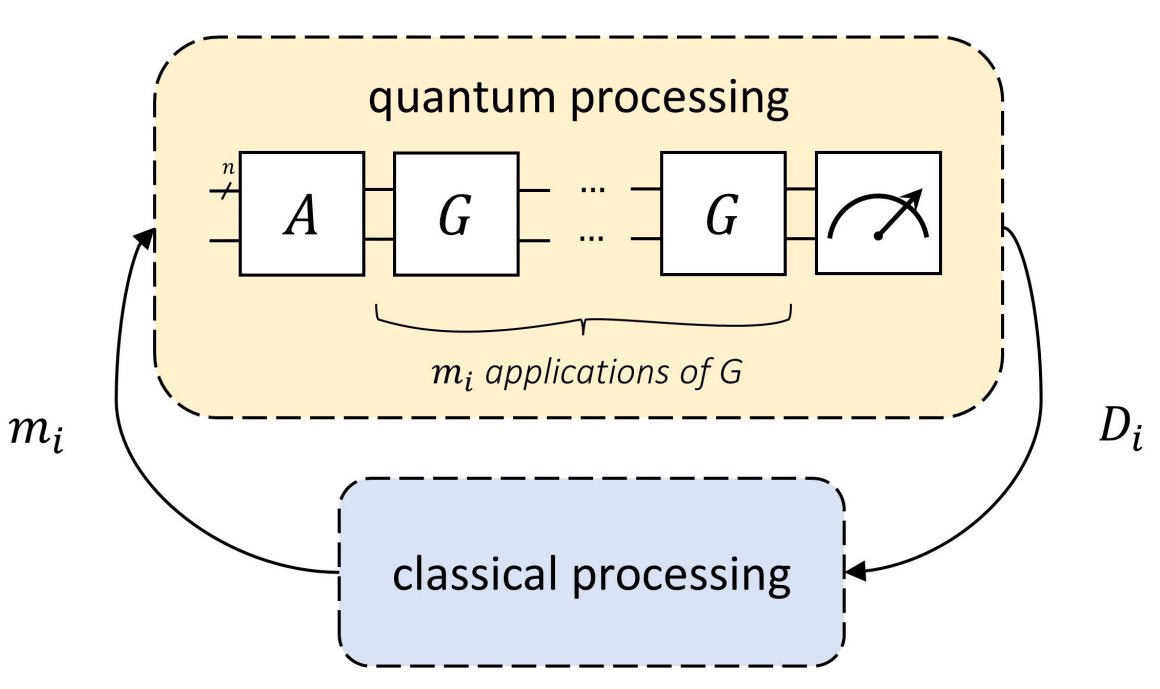

Many algorithms for amplitude estimation follow this template, differing only on the classical processing side: how to process the measurement information, and how to choose the next $m$. These decisions specify the algorithms, and determine their performance and costs (both quantum and classical). Some examples:

- [Iterative quantum amplitude estimation](https://arxiv.org/pdf/1912.05559)
- [Amplitude Estimation without phase estimation](https://arxiv.org/pdf/1904.10246)
- [Faster Amplitude Estimation](https://arxiv.org/pdf/2003.02417)
- [Quantum Approximate Counting, Simplified.](https://arxiv.org/pdf/1908.10846)*

The last reference actually proves that this **adaptive workflow** can provably achieve the **full quantum advantage**, which is remarkable for a hybrid quantum algorithm!

*_Note_: quantum counting is closely related to amplitude estimation, but focuses on counting the number of solutions rather than estimating their fraction. Regardless, the paper also generalizes the result to QAE.

## 5.5 Maximum likelihood quantum amplitude estimation

We will consider the simplest possible strategy. Recall our previous approaches to parameter learning for qubits: we chose a set of times, measured, and processed the whole dataset using maximum likelihood estimation or Bayesian inference.

This is precisely the idea of the paper "[Amplitude estimation without phase estimation](https://arxiv.org/pdf/1904.10246)". They do a bunch of measurements, and then apply maximum likelihood estimation. The question remains: how to choose the $m$s? Keeping things simple, the authors consider two options:
- Linear increasing sequence (LIS): ms = $[0, 1, 2, 3, 4, ...]$
- Exponential increasing sequence (EIS): ms = $[0, 2^1, 2^2, 2^3, 2^4, ...]$

Let's try LIS first, using the Grover implementation from before. To interpret the results, remember that we defined `nqubits = 4` and 1 good state, so $a = 0.0625$.

Start by plotting the likelihood.


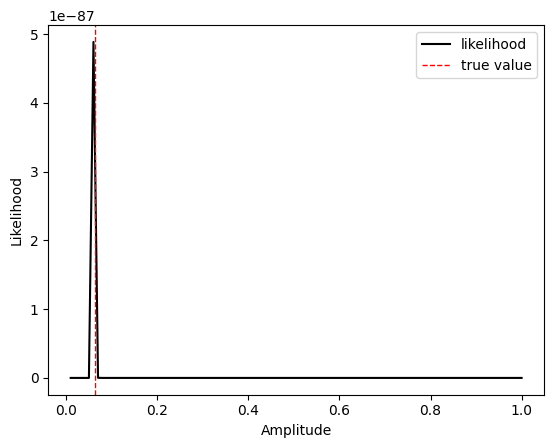

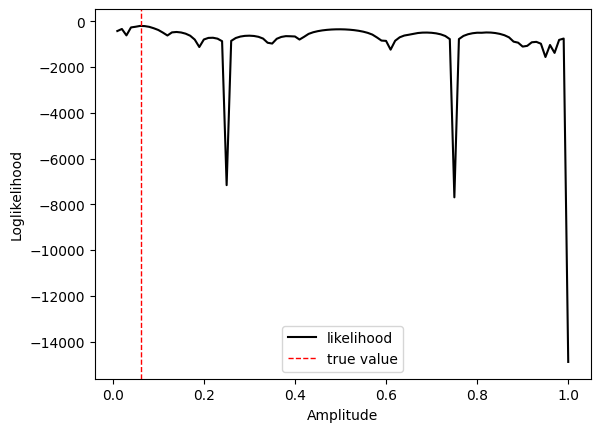

In [4]:
def likelihood(a, ms, xs, nshots, log):
  if log:
      return loglikelihood(a, ms, xs, nshots)
  l = 1
  for m,x in zip(ms, xs):
      arg = (2*m+1)*np.arcsin(a**0.5)
      l *= np.sin(arg)**(2*x)*np.cos(arg)**(2*(nshots-x))
  return l

def loglikelihood(a, ms, xs, nshots):
    def kth_loglikelihood(k):
        arg = (2*ms[k]+1)*np.arcsin(a**0.5)
        lk = 0
        if xs[k]!=0:
            lk += 2*xs[k]*np.log(np.abs(np.sin(arg)))
        if (nshots-xs[k])!=0:
            lk += 2*(nshots-xs[k])*np.log(np.abs(np.cos(arg)))
        return lk
    lks = [kth_loglikelihood(k) for k in range(len(xs))]
    l = np.sum(lks)
    return l

def plot_likelihood(ms, xs, Nshots, a_true, log = False):
    aa = np.linspace(0.01,1,100)
    ls = [likelihood(a, ms, xs, nshots, log) for a in aa]
    plt.plot(aa, ls, label = "likelihood", color = "black")
    plt.xlabel("Amplitude")
    plt.ylabel(f"{"Logl" if log else "L"}ikelihood")
    plt.axvline(x = a_true, color = 'r', linestyle = "--", linewidth = 1,
                label = "true value")
    plt.legend()
    plt.show()

nshots = 100
ms = [i for i in range(5)]
xs = grover_good_counts(ms)
plot_likelihood(ms, xs, nshots, 1/2**nqubits, log = False)
plot_likelihood(ms, xs, nshots, 1/2**nqubits, log = True)

Now we can maximize it to obtain quantitative results.

In [5]:
def maximize_likelihood(ms, xs, Nshots, log):
    f = lambda a: -likelihood(a, ms, xs, Nshots, log)
    a_opt = brute(f, ranges = [(0.01,1)], Ns = 1e3)
    return a_opt[0]

mle = maximize_likelihood(ms, xs, nshots, log = False)
mle2 = maximize_likelihood(ms, xs, nshots, log = True)
print("> Real amplitude: ", a_true)
print("> Maximum likelihood estimate: ", mle)
print("> Maximum loglikelihood estimate: ", mle2)

> Real amplitude:  0.0625
> Maximum likelihood estimate:  0.06191610360360361
> Maximum loglikelihood estimate:  0.06194013935810812


Finally, to assess the estimation performance, we calculate averages over runs as we did for the frequency estimation in the previous tutorial. Here we add also EIS for comparison, as well as the fundamental limits of metrology:
- The standard quantum limit (SQL), which is the best achievable performance for classical algorithms.
- The Heisenberg limit (HL), which is the best achievable performance for quantum algorithms, and quadratically faster than the SQL.

The flag `run_again` is set to true because this takes a while to run, so I ran this in advance and hardcoded the results. But do try running it yourself -- you can even try different sequences for $m$!

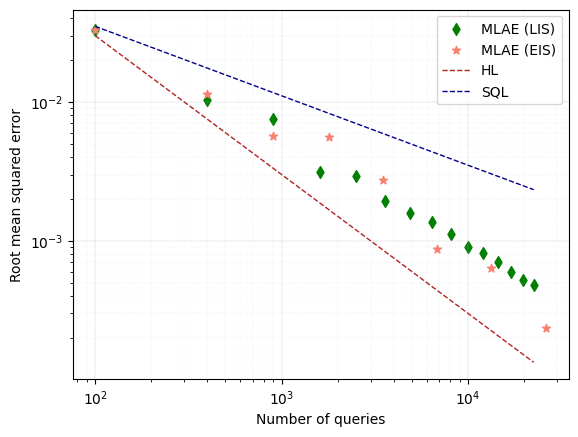

In [6]:
def mlae(ms, nruns, nshots, a_true, log = True):
    all_errs = []

    for run in range(nruns):
        xs = []
        es = []
        Nqs = []
        for i in range(1, len(ms) + 1):
            xs = grover_good_counts(ms)
            a = maximize_likelihood(ms[:i], xs[:i], nshots, log = log)
            e = (a_true-a)**2
            es.append(e)
        all_errs.append(es)

    all_errs = np.array(all_errs)
    rmses = np.sqrt(np.mean(all_errs, axis = 0))
    Nqs = [(2*m+1)*nshots for m in ms]
    Nqs = np.cumsum(Nqs)
    return Nqs, rmses

def plot_evol(lNqs, lerrs, llabels, Chl = 3, Csql = 0.35, log = True):
    fig, ax = plt.subplots(1)
    for Nqs, errs, label in zip(lNqs, lerrs, llabels):
        color = "green" if "LIS" in label else "salmon"
        marker = "d" if "LIS" in label else "*"
        ax.scatter(Nqs, errs, label = label, marker = marker, color = color)

    Nqs = lNqs[0]
    yhl = [Chl*float(Nq)**-1 for Nq in lNqs[0]]
    ax.plot(Nqs, yhl, label = "HL", linewidth = 1, linestyle = "--", color = "firebrick")
    ysql = [Csql*float(Nq)**-0.5 for Nq in lNqs[0]]
    ax.plot(Nqs, ysql, label = "SQL", linewidth = 1, linestyle = "--", color = "darkblue")

    if log:
        ax.set_xscale('log')
        ax.set_yscale('log')
    plt.xlabel("Number of queries")
    plt.ylabel("Root mean squared error")
    plt.legend()

    plt.minorticks_on() # Enable minor ticks
    plt.grid(which='major', linestyle='--', linewidth=0.25)
    plt.grid(which='minor', linestyle=':', linewidth=0.12)

    plt.show()

run_again = False
if run_again:
    Nshots = 100
    Nruns = 10
    ms1 = [i for i in range(15)]
    ms2 = [0] + [2**i for i in range(7)]
    Nqs1, errs1 = mlae(ms1, Nruns, nshots, a_true, log = True)
    Nqs2, errs2 = mlae(ms2, Nruns, nshots, a_true, log = True)
else:
    Nqs1 = [100, 400, 900, 1600, 2500, 3600, 4900, 6400, 8100, 10000, 12100, 14400, 16900, 19600, 22500]
    errs1 = [0.032758892400746156, 0.01034995636040917, 0.007556081137204353, 0.003121950260032232, 0.0029232499190655855, 0.0019394875984209714, 0.0015761990961750188, 0.00136630539800486, 0.001122975883121774, 0.0009005410393646197, 0.000819437860150627, 0.0006982465034571229, 0.0005952486345942543, 0.0005259752201177109, 0.0004773014157460129]
    Nqs2 = [100, 400, 900, 1800, 3500, 6800, 13300, 26200]
    errs2 = [0.03294252063286527, 0.011303814586598656, 0.005690496357656447, 0.005553004545907382, 0.002743626723881261, 0.0008679506750282148, 0.0006382076413549914, 0.00023606104865387306]
plot_evol([Nqs1, Nqs2], [errs1, errs2], ["MLAE (LIS)", "MLAE (EIS)"])

## 5.6 Bayesian quantum amplitude estimation

While the maximum likelihood approach works remarkably well considering its simplicity, it is not optimal: neither sequence saturates the Heisenberg limit. Furthermore, it does not offer a principled path towards improvement, because the choice of coefficients is completely empirical.

Here enters Bayesian inference: we can follow exactly the same path of experimental design as we did in the previous tutorial. Indeed, the problems are extremely similar!

Here the workflow becomes:



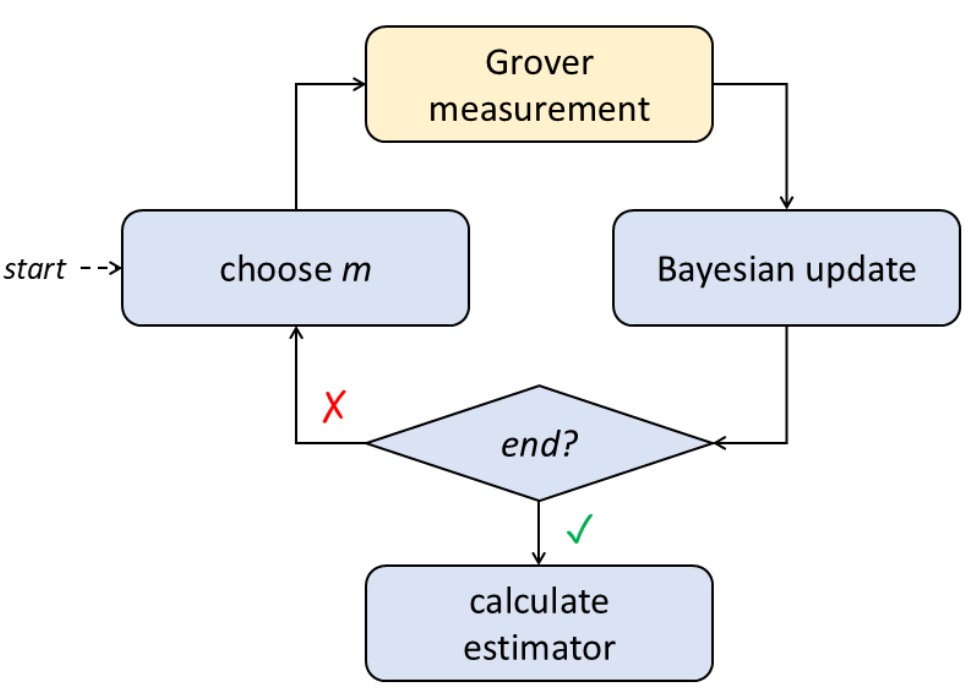

[This algorithm](https://arxiv.org/pdf/2412.04394) has been numerically shown to achieve the Heisenberg limit for the general case, and to outperform other QAE algorithms. It also offers perks that the others don't: for instance, the generality of the Bayesian framework means that we can optimize the experiments even if the measurements are imperfect due to limitations of the quantum computer. We need only model these imperfections, and consider them in the likelihood function. In constrast, most other algorithms follow rigid pre-established rules that don't straightforwardly generalize to noise models.

**Implement Bayesian experimental design for amplitude estimation**, adapting the ideas of the previous tutorials to this new setting. Note that the paper above employs some tricks to lighten the classical processing load and improve scalability, but you should be able to make a working implementation of Bayesian QAE just with the ideas we followed in this course.

In [6]:
# Write your code below.

## 5.7 Other Bayes-Quantum interactions

During this course, we focused on how **Bayesian inference** can be useful for **quantum metrology** and **quantum algorithms**. This straightforwardly generalizes to applications in **quantum sensing**, **qubit calibration**, etc. We already saw some papers illustrating these applications in tutorial #1 (Qubits and Bayesian Statistics 101).

These are very useful and wide-ranging applications, but they're far from being the only cases where quantum computers and Bayesian inference can aid one another. And note that this is a bidirectional relation: **quantum computing can also be useful for Bayesian methods**!

For instance, quantum algorithms can accelerate key sub-routines of Bayesian inference. In particular, quantum amplitude estimation, the algorithm we discussed here, can speed up Monte Carlo integration, which is widely used to deal with Bayesian probability distributions. Here are some other examples:


- [Adaptive Quantum Simulated Annealing for Bayesian Inference
and Estimating Partition Functions](https://arxiv.org/pdf/1907.09965)
- [Quantum Metropolis Sampling](https://arxiv.org/pdf/0911.3635)
- [Quantum Dynamical Hamiltonian Monte Carlo](https://arxiv.org/pdf/2403.01775)
- [Quantum speedup of Monte Carlo methods](https://arxiv.org/pdf/1504.06987)
- [Quantum Inference on Bayesian Networks](https://arxiv.org/pdf/1402.7359)
- [Hybrid quantum-classical algorithm for near-optimal planning in POMDPs](https://arxiv.org/pdf/2507.18606)
- [Quantum Bayesian decision-making](https://arxiv.org/pdf/2010.02088)

Note that these reading suggestions are far from being comprehensive; they're merely intended to provide a broad view of the scope of the techniques we discussed.

Quantum mechanics are a rich source of probabilistic phenomena, and Bayesian statistics are a rich framework to deal with probabilistic phenomena. So they make a very interesting match!





## 5.8 Conclusion

This ends the sequence of tutorials! I hope you enjoyed learning about this, and feel free to reach out to me on Discord or [by email](mailto:alexandraramoaalves@gmail.com).